# Desafio: Contacts Application (Prefix Search)

Neste desafio, vamos construir nossa própria aplicação de contatos. A aplicação deve ser capaz de realizar duas operações principais de forma eficiente.

## 📝 Descrição do Problema

A aplicação deve processar $n$ operações sequenciais:

1.  **`add name`**: Onde `name` é uma string que denota o nome de um contato. Este nome deve ser armazenado na aplicação.
2.  **`find partial`**: Onde `partial` é uma string que denota um prefixo a ser buscado. Você deve contar quantos contatos armazenados começam com esse prefixo e imprimir o valor.

### Formato de Entrada
*   A primeira linha contém um único inteiro **n**, o número de operações.
*   As **n** linhas seguintes contêm uma operação em uma das duas formas definidas acima (`add` ou `find`).

### Restrições
*   $1 \leq n \leq 10^5$
*   $1 \leq |name| \leq 21$
*   $1 \leq |partial| \leq 21$
*   É garantido que `name` e `partial` contenham apenas letras minúsculas do alfabeto inglês.
*   Não haverá nomes duplicados na operação `add`.

### Formato de Saída
Para cada operação `find partial`, imprima o número de contatos que começam com aquele prefixo em uma nova linha.

---

## 📥 Exemplo de Entrada
```text
4
add hack
add hackerrank
find hac
find hak
```

## 📤 Exemplo de Saída
```text
2
0
```

---

## 💡 Explicação Passo a Passo

1.  **add hack**: Adicionamos o contato "hack".
2.  **add hackerrank**: Adicionamos "hackerrank".
3.  **find hac**: Existem dois contatos que começam com "hac" ("hack" e "hackerrank"). Saída: **2**.
4.  **find hak**: Nenhum contato começa com "hak". Saída: **0**.

---

## 🚀 Dica para a Solução: Estrutura de Dados Trie

Para lidar com $10^5$ operações de busca de prefixo, uma busca linear ($O(N)$ para cada query) será muito lenta. A estrutura ideal aqui é uma **Trie** (árvore de prefixos).

**Otimização:** Para tornar a operação `find` instantânea ($O(1)$ após percorrer o prefixo), adicione um contador em cada nó da Trie que rastreia quantas palavras passam por aquele nó durante a inserção (`add`).

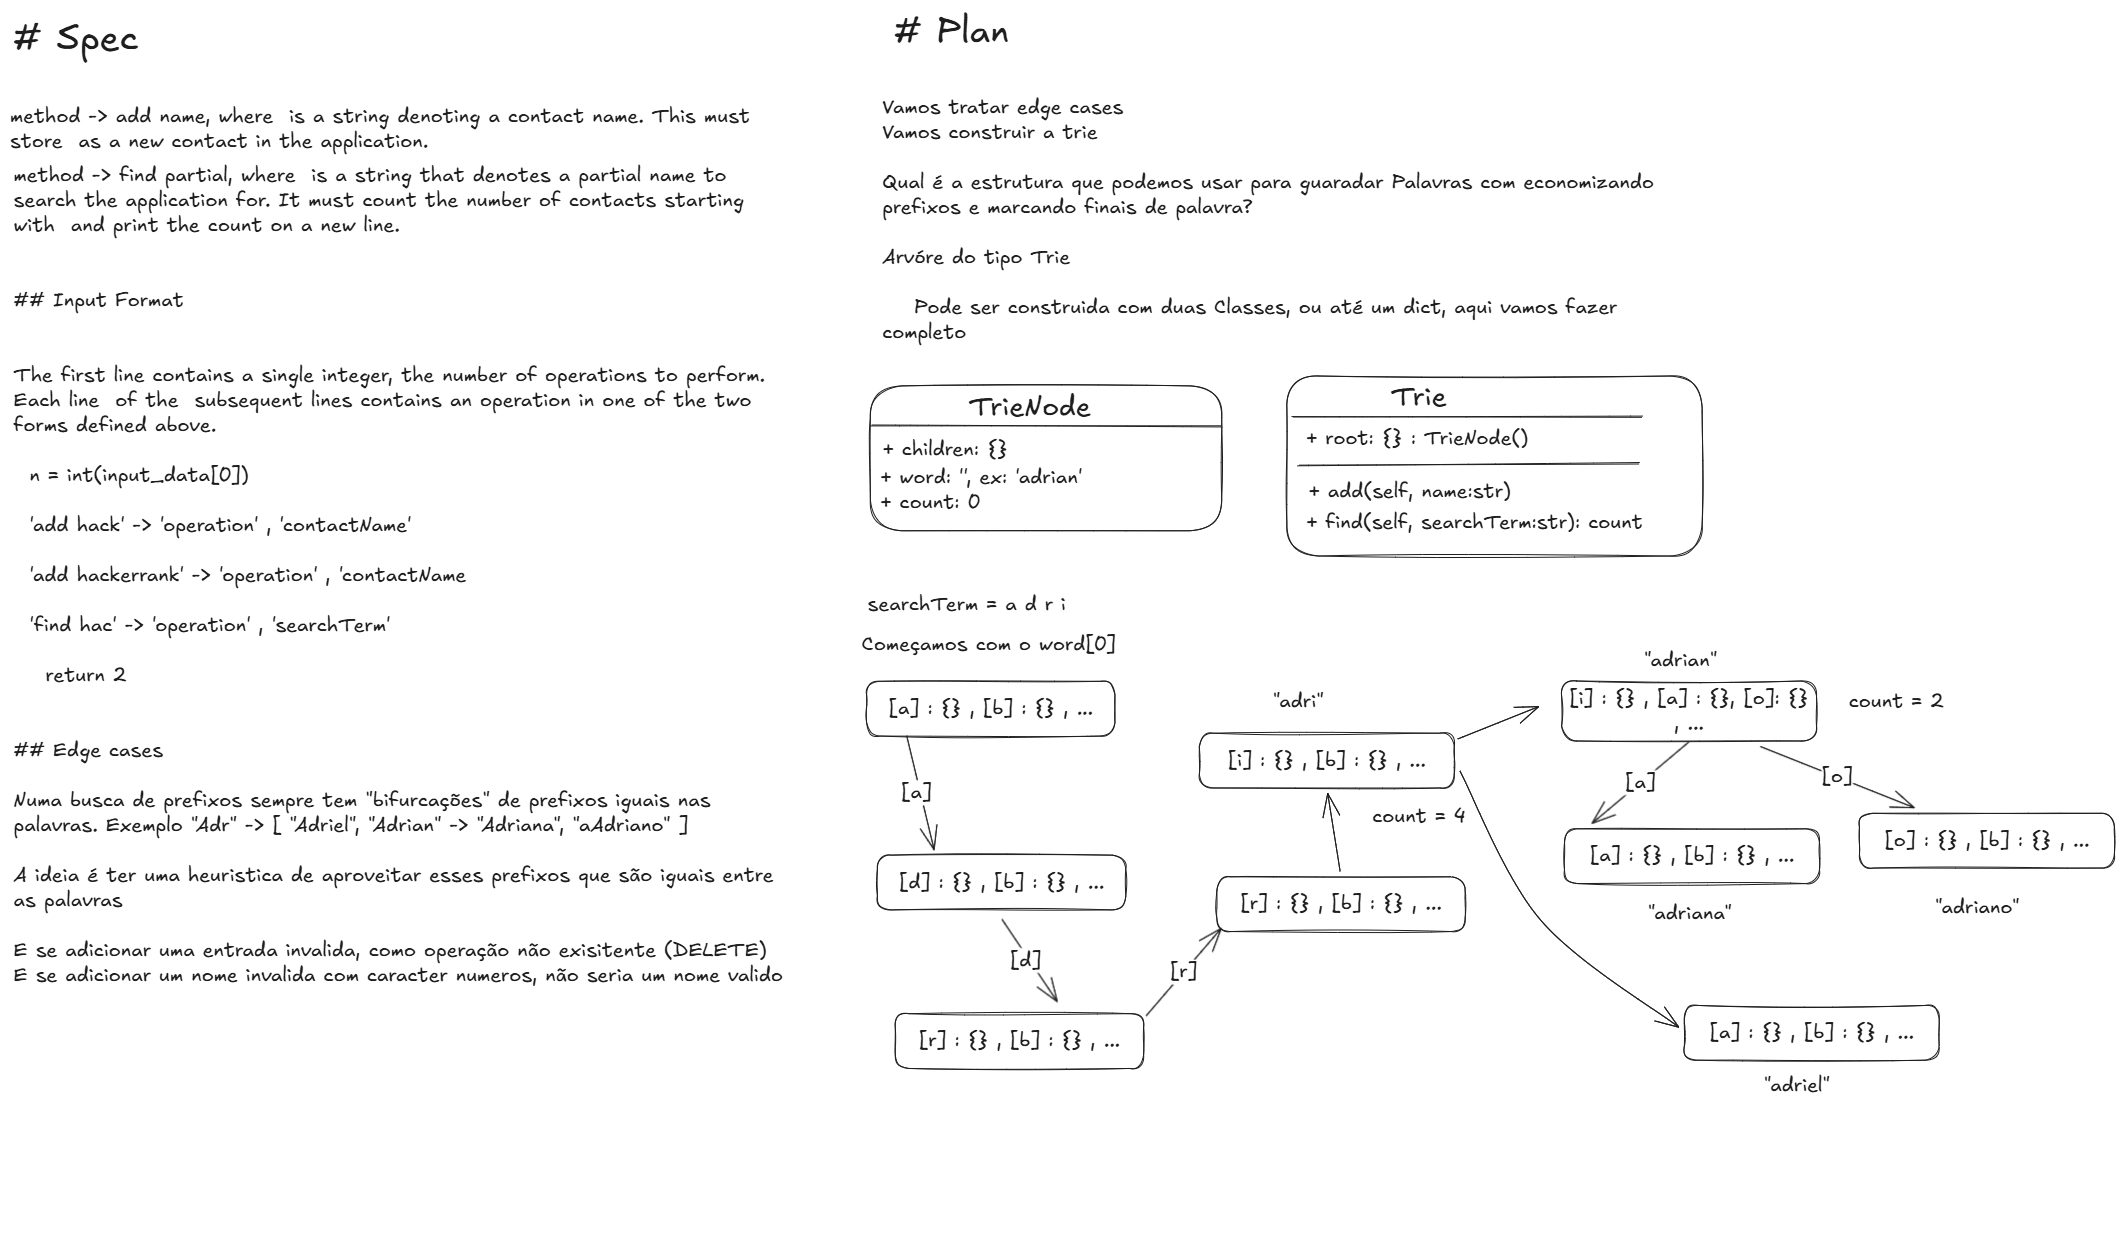

In [ ]:
import sys

class TrieNode:
    def __init__(self):
        self.children = {}
        self.count = 0
        self.word = ''

class Trie:
    def __init__(self):
        self.root = TrieNode()

    def add(self, word: str) -> None:
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
            node.count += 1
        self.word = ''

    def find(self, word: str) -> int:
        node = self.root
        for char in word:
            if char not in node.children:
                return 0
            node = node.children[char]
        return node.count

if __name__ == '__main__':
    input_data = sys.stdin.read().splitlines()
    if not input_data:
        sys.exit(0)

    n = int(input_data[0])
    trie = Trie()
    for i in range(1, n + 1):
        query = input_data[i].split()
        if not query:
            continue
        
        operation = query[0]
        value = query[1]

        if operation == 'add':
            trie.add(value)
        elif operation == 'find':
            sys.stdout.write(str(trie.find(value)) + '\n')
        else:
            raise ValueError("Invalid operation")
